## Etapa 3: Segmentação

Caminho: E:\VISÃO COMPUTACIONAL\Projeto Final\DATASET\preprocessed\normal\fresh\freshapples\imagem1.png
Imagem carregada com sucesso! Shape: (386, 470, 3)


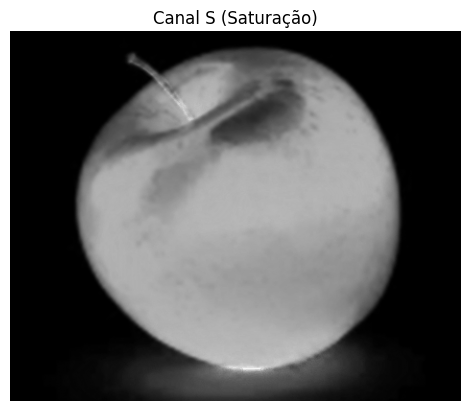

In [ ]:
import cv2
import matplotlib.pyplot as plt
import numpy as np
import os

def carregar_imagem_bgr(caminho):
    with open(caminho, 'rb') as f:
        dados = np.frombuffer(f.read(), np.uint8)
    img = cv2.imdecode(dados, cv2.IMREAD_COLOR)
    return img

pasta = r"E:\VISÃO COMPUTACIONAL\Projeto Final\DATASET\preprocessed\normal\fresh\freshapples"
arquivos = os.listdir(pasta)
caminho_teste = os.path.join(pasta, arquivos[0])
print("Caminho:", caminho_teste)

img = carregar_imagem_bgr(caminho_teste)
if img is None:
    print("Ainda não foi possível carregar. Verifique se o arquivo não está corrompido.")
else:
    print("Imagem carregada com sucesso! Shape:", img.shape)
    hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)
    s = hsv[:, :, 1]

    plt.imshow(s, cmap='gray')
    plt.title('Canal S (Saturação)')
    plt.axis('off')
    plt.show()

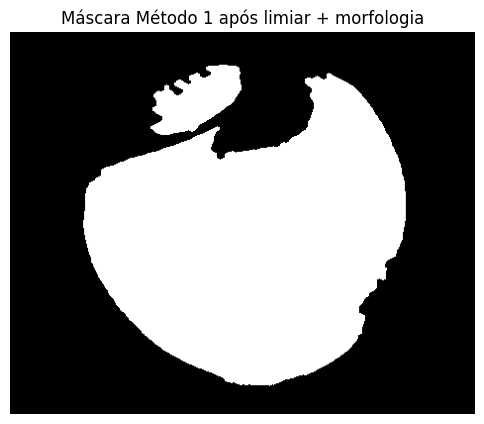

In [14]:
valor_limiar = 127
_, mascara = cv2.threshold(s, valor_limiar, 255, cv2.THRESH_BINARY)

kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (5, 5))

mascara = cv2.morphologyEx(mascara, cv2.MORPH_CLOSE, kernel)

mascara = cv2.morphologyEx(mascara, cv2.MORPH_OPEN, kernel)

plt.figure(figsize=(6,6))
plt.imshow(mascara, cmap='gray')
plt.title('Máscara Método 1 após limiar + morfologia')
plt.axis('off')
plt.show()

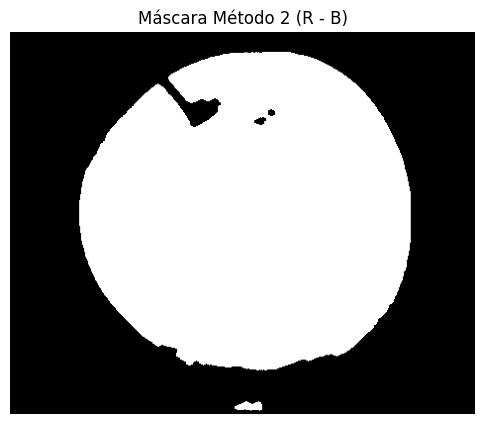

In [15]:
b, g, r = cv2.split(img)

diff = cv2.subtract(r, b)

_, mascara2 = cv2.threshold(diff, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (5, 5))
mascara2 = cv2.morphologyEx(mascara2, cv2.MORPH_CLOSE, kernel)
mascara2 = cv2.morphologyEx(mascara2, cv2.MORPH_OPEN, kernel)

plt.figure(figsize=(6,6))
plt.imshow(mascara2, cmap='gray')
plt.title('Máscara Método 2 (R - B)')
plt.axis('off')
plt.show()

In [ ]:
def carregar_imagem_bgr(caminho):
    with open(caminho, 'rb') as f:
        dados = np.frombuffer(f.read(), np.uint8)
    img = cv2.imdecode(dados, cv2.IMREAD_COLOR)
    return img

def segmentar_rb(img_bgr):
    b, g, r = cv2.split(img_bgr)
    diff = cv2.subtract(r, b)
    _, mascara = cv2.threshold(diff, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (5, 5))
    mascara = cv2.morphologyEx(mascara, cv2.MORPH_CLOSE, kernel)
    mascara = cv2.morphologyEx(mascara, cv2.MORPH_OPEN, kernel)
    return mascara

base_path = r"E:\VISÃO COMPUTACIONAL\Projeto Final\DATASET\normal"
prep_base = r"E:\VISÃO COMPUTACIONAL\Projeto Final\DATASET\preprocessed\normal"
mask_base = r"E:\VISÃO COMPUTACIONAL\Projeto Final\DATASET\masks"

total_ok = 0
for classe in classes:
    for caminho_original in imagens_por_classe[classe]:
        rel_path = os.path.relpath(caminho_original, base_path)
        caminho_img = os.path.join(prep_base, rel_path)
        caminho_mask = os.path.join(mask_base, rel_path)
        caminho_mask = os.path.splitext(caminho_mask)[0] + '.png'
        
        os.makedirs(os.path.dirname(caminho_mask), exist_ok=True)
        print("Processando:", caminho_img)
        img = cv2.imread(caminho_img)
        if img is None:
            img = carregar_imagem_bgr(caminho_img)
        if img is None:
            print("Erro ao carregar:", caminho_img)
            continue

        mascara = segmentar_rb(img)
  
        sucesso = cv2.imwrite(caminho_mask, mascara)
        if not sucesso:
            ext = os.path.splitext(caminho_mask)[1]
            ret, buf = cv2.imencode(ext, mascara)
            if ret:
                with open(caminho_mask, 'wb') as f:
                    f.write(buf.tobytes())
                sucesso = True
        if sucesso:
            total_ok += 1
        else:
            print("Falha ao salvar:", caminho_mask)

print("Máscaras salvas:", total_ok)

Processando: E:\VISÃO COMPUTACIONAL\Projeto Final\DATASET\preprocessed\normal\fresh\freshapples\imagem1.png
Processando: E:\VISÃO COMPUTACIONAL\Projeto Final\DATASET\preprocessed\normal\fresh\freshapples\imagem10.png
Processando: E:\VISÃO COMPUTACIONAL\Projeto Final\DATASET\preprocessed\normal\fresh\freshapples\imagem100.png
Processando: E:\VISÃO COMPUTACIONAL\Projeto Final\DATASET\preprocessed\normal\fresh\freshapples\imagem101.png
Processando: E:\VISÃO COMPUTACIONAL\Projeto Final\DATASET\preprocessed\normal\fresh\freshapples\imagem102.png
Processando: E:\VISÃO COMPUTACIONAL\Projeto Final\DATASET\preprocessed\normal\fresh\freshapples\imagem103.png
Processando: E:\VISÃO COMPUTACIONAL\Projeto Final\DATASET\preprocessed\normal\fresh\freshapples\imagem104.png
Processando: E:\VISÃO COMPUTACIONAL\Projeto Final\DATASET\preprocessed\normal\fresh\freshapples\imagem105.png
Processando: E:\VISÃO COMPUTACIONAL\Projeto Final\DATASET\preprocessed\normal\fresh\freshapples\imagem106.png
Processando: 